# Automating Crypto Website API Pull

In [19]:
from requests import Request, Session
from requests.exceptions import ConnectionError, Timeout, TooManyRedirects
import json

url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
parameters = {
  'start':'1',
  'limit':'15',
  'convert':'USD'
}
headers = {
  'Accepts': 'application/json',
  'X-CMC_PRO_API_KEY': '8d36aea2-9ccb-4f8d-909c-2b085cbc4945',
}

session = Session()
session.headers.update(headers)

try:
  response = session.get(url, params=parameters)
  data = json.loads(response.text)
  print(data)
except (ConnectionError, Timeout, TooManyRedirects) as e:
  print(e)

{'status': {'timestamp': '2024-10-06T16:26:58.951Z', 'error_code': 0, 'error_message': None, 'elapsed': 37, 'credit_count': 1, 'notice': None, 'total_count': 9845}, 'data': [{'id': 1, 'name': 'Bitcoin', 'symbol': 'BTC', 'slug': 'bitcoin', 'num_market_pairs': 11755, 'date_added': '2010-07-13T00:00:00.000Z', 'tags': ['mineable', 'pow', 'sha-256', 'store-of-value', 'state-channel', 'coinbase-ventures-portfolio', 'three-arrows-capital-portfolio', 'polychain-capital-portfolio', 'binance-labs-portfolio', 'blockchain-capital-portfolio', 'boostvc-portfolio', 'cms-holdings-portfolio', 'dcg-portfolio', 'dragonfly-capital-portfolio', 'electric-capital-portfolio', 'fabric-ventures-portfolio', 'framework-ventures-portfolio', 'galaxy-digital-portfolio', 'huobi-capital-portfolio', 'alameda-research-portfolio', 'a16z-portfolio', '1confirmation-portfolio', 'winklevoss-capital-portfolio', 'usv-portfolio', 'placeholder-ventures-portfolio', 'pantera-capital-portfolio', 'multicoin-capital-portfolio', 'para

In [3]:
type(data)

dict

In [75]:
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [62]:
df = pd.json_normalize(data["data"])
df["timestamp"] = pd.to_datetime("now")
df

,id,name,symbol,slug,num_market_pairs,date_added,tags,max_supply,circulating_supply,total_supply,infinite_supply,platform,cmc_rank,self_reported_circulating_supply,self_reported_market_cap,tvl_ratio,last_updated,quote.USD.price,quote.USD.volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.name,platform.symbol,platform.slug,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,11755,2010-07-13T00:00:00.000Z,"[mineable, pow, sha-256, store-of-value, state...",2.100000e+07,1.976392e+07,1.976392e+07,False,NaN,1,NaN,NaN,None,2024-10-06T16:26:00.000Z,62720.840140,1.366972e+10,-20.4710,0.265363,0.875268,-4.574709,15.800595,11.478783,12.687595,1.239610e+12,56.7626,1.317138e+12,None,2024-10-06T16:26:00.000Z,NaN,NaN,NaN,NaN,NaN,2024-10-06 17:01:45.273401
1,1027,Ethereum,ETH,ethereum,9378,2015-08-07T00:00:00.000Z,"[pos, smart-contracts, ethereum-ecosystem, coi...",NaN,1.203773e+08,1.203773e+08,True,NaN,2,NaN,NaN,None,2024-10-06T16:25:00.000Z,2441.731144,8.163246e+09,-12.1756,-0.145569,1.191962,-8.355565,6.974125,1.606373,-17.703969,2.939291e+11,13.4576,2.939291e+11,None,2024-10-06T16:25:00.000Z,NaN,NaN,NaN,NaN,NaN,2024-10-06 17:01:45.273401
2,825,Tether USDt,USDT,tether,99436,2015-02-25T00:00:00.000Z,"[stablecoin, asset-backed-stablecoin, avalanch...",NaN,1.196773e+11,1.213726e+11,True,NaN,3,NaN,NaN,None,2024-10-06T16:25:00.000Z,0.999925,2.960885e+10,-13.1087,0.000313,-0.010750,-0.017807,0.060104,-0.026976,0.024710,1.196684e+11,5.4790,1.213636e+11,None,2024-10-06T16:25:00.000Z,1027.0,Ethereum,ETH,ethereum,0xdac17f958d2ee523a2206206994597c13d831ec7,2024-10-06 17:01:45.273401
3,1839,BNB,BNB,bnb,2252,2017-07-25T00:00:00.000Z,"[marketplace, centralized-exchange, payments, ...",NaN,1.459325e+08,1.459325e+08,False,NaN,4,NaN,NaN,None,2024-10-06T16:25:00.000Z,566.523892,1.386757e+09,-3.7713,-0.028622,0.551266,-5.215532,15.429190,18.125316,13.195613,8.267425e+10,3.7867,8.267425e+10,None,2024-10-06T16:25:00.000Z,NaN,NaN,NaN,NaN,NaN,2024-10-06 17:01:45.273401
4,5426,Solana,SOL,solana,749,2020-04-10T00:00:00.000Z,"[pos, platform, solana-ecosystem, cms-holdings...",NaN,4.685892e+08,5.859755e+08,True,NaN,5,NaN,NaN,None,2024-10-06T16:25:00.000Z,145.527500,1.068070e+09,-23.1949,-0.072166,1.862594,-7.353059,13.832752,-2.148744,6.375954,6.819261e+10,3.1250,8.527555e+10,None,2024-10-06T16:25:00.000Z,NaN,NaN,NaN,NaN,NaN,2024-10-06 17:01:45.273401
5,3408,USDC,USDC,usd-coin,22304,2018-10-08T00:00:00.000Z,"[medium-of-exchange, stablecoin, asset-backed-...",NaN,3.558534e+10,3.558534e+10,False,NaN,6,NaN,NaN,None,2024-10-06T16:25:00.000Z,0.999946,2.394446e+09,-31.3295,0.000299,-0.013780,0.003509,-0.002325,-0.000482,-0.003329,3.558344e+10,1.6294,3.558344e+10,None,2024-10-06T16:25:00.000Z,1027.0,Ethereum,ETH,ethereum,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2024-10-06 17:01:45.273401
6,52,XRP,XRP,xrp,1400,2013-08-04T00:00:00.000Z,"[medium-of-exchange, enterprise-solutions, arr...",1.000000e+11,5.656404e+10,9.998716e+10,False,NaN,7,NaN,NaN,None,2024-10-06T16:26:00.000Z,0.535837,6.154000e+08,-25.1755,0.374861,1.076591,-18.316498,2.060021,7.248909,26.554978,3.030911e+10,1.3877,5.358371e+10,None,2024-10-06T16:26:00.000Z,NaN,NaN,NaN,NaN,NaN,2024-10-06 17:01:45.273401
7,74,Dogecoin,DOGE,dogecoin,1076,2013-12-15T00:00:00.000Z,"[mineable, pow, scrypt, medium-of-exchange, me...",NaN,1.462555e+11,1.462555e+11,True,NaN,8,NaN,NaN,None,2024-10-06T16:26:00.000Z,0.111795,4.211657e+08,-2.5617,0.198567,2.041161,-11.280065,20.230921,14.356216,5.789632,1.635071e+10,0.7493,1.635071e+10,None,2024-10-06T16:26:00.000Z,NaN,NaN,NaN,NaN,NaN,2024-10-06 17:01:45.273401
8,1958,TRON,TRX,tron,1043,2017-09-13T00:00:00.000Z,"[media, payments, tron-ecosystem, layer-1, dwf...",NaN,8.658336e+10,8.

In [79]:
# Creating a function to pull data from the API
def api_runner():
    global df
    url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
    parameters = {
      'start':'1',
      'limit':'15',
      'convert':'USD'
    }
    headers = {
      'Accepts': 'application/json',
      'X-CMC_PRO_API_KEY': '8d36aea2-9ccb-4f8d-909c-2b085cbc4945',
    }
    
    session = Session()
    session.headers.update(headers)
    
    try:
      response = session.get(url, params=parameters)
      data = json.loads(response.text)
      #print(data)
    except (ConnectionError, Timeout, TooManyRedirects) as e:
      print(e)

    df = pd.json_normalize(data["data"])
    df["timestamp"] = pd.to_datetime("now")
    df

    if not os.path.isfile(r"C:\Users\Hp\OneDrive\Documents\Python Scripts\API.csv"):
        df.to_csv(r"C:\Users\Hp\OneDrive\Documents\Python Scripts\API.csv", header="column_names")
    else:
        df.to_csv(r"C:\Users\Hp\OneDrive\Documents\Python Scripts\API.csv",mode="a" ,header=False)

In [81]:
import os
from time import time
from time import sleep

for i in range(333):
    api_runner()
    print("API Runner Completed Successfully")
    sleep(60) # Sleep for 1 minute
exit()

API Runner Completed Successfully
API Runner Completed Successfully
API Runner Completed Successfully


KeyboardInterrupt: 

In [91]:
df3 = pd.read_csv(r"C:\Users\Hp\OneDrive\Documents\Python Scripts\API.csv")
df3

,Unnamed: 0,id,name,symbol,slug,num_market_pairs,date_added,tags,max_supply,circulating_supply,total_supply,infinite_supply,platform,cmc_rank,self_reported_circulating_supply,self_reported_market_cap,tvl_ratio,last_updated,quote.USD.price,quote.USD.volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.name,platform.symbol,platform.slug,platform.token_address,timestamp
0,0,1,Bitcoin,BTC,bitcoin,11755,2010-07-13T00:00:00.000Z,"['mineable', 'pow', 'sha-256', 'store-of-value...",21000000.00000,19764040.00000,19764040.00000,False,NaN,1,NaN,NaN,NaN,2024-10-06T22:36:00.000Z,62518.28700,14184198194.15773,4.35130,-0.10995,0.77979,-5.00023,16.28747,13.40541,10.09055,1235613924926.63379,56.87030,1312884026922.60010,NaN,2024-10-06T22:36:00.000Z,NaN,NaN,NaN,NaN,NaN,2024-10-06 22:37:32.601502
1,1,1027,Ethereum,ETH,ethereum,9378,2015-08-07T00:00:00.000Z,"['pos', 'smart-contracts', 'ethereum-ecosystem...",NaN,120377344.45751,120377344.45751,True,NaN,2,NaN,NaN,NaN,2024-10-06T22:35:00.000Z,2425.14270,8229438408.46082,0.27080,-0.52456,0.46207,-9.00543,9.33133,3.55532,-20.02453,291932237801.91040,13.43680,291932237801.90997,NaN,2024-10-06T22:35:00.000Z,NaN,NaN,NaN,NaN,NaN,2024-10-06 22:37:32.601502
2,2,825,Tether USDt,USDT,tether,99436,2015-02-25T00:00:00.000Z,"['stablecoin', 'asset-backed-stablecoin', 'ava...",NaN,119677344821.66928,121372645796.94348,True,NaN,3,NaN,NaN,NaN,2024-10-06T22:35:00.000Z,1.00003,30352202159.10662,1.96630,-0.00252,0.00491,-0.00933,0.03874,-0.02978,-0.00833,119681105932.72716,5.50860,121376460186.38000,NaN,2024-10-06T22:35:00.000Z,1027.00000,Ethereum,ETH,ethereum,0xdac17f958d2ee523a2206206994597c13d831ec7,2024-10-06 22:37:32.601502
3,3,1839,BNB,BNB,bnb,2252,2017-07-25T00:00:00.000Z,"['marketplace', 'centralized-exchange', 'payme...",NaN,145932499.03000,145932499.03000,False,NaN,4,NaN,NaN,NaN,2024-10-06T22:35:00.000Z,565.89717,1386342078.16224,-2.80810,-0.17886,0.52846,-5.59264,16.79843,19.47290,10.64488,82582788816.30991,3.80090,82582788816.31000,NaN,2024-10-06T22:35:00.000Z,NaN,NaN,NaN,NaN,NaN,2024-10-06 22:37:32.601502
4,4,5426,Solana,SOL,solana,749,2020-04-10T00:00:00.000Z,"['pos', 'platform', 'solana-ecosystem', 'cms-h...",NaN,468586788.74642,585974106.79156,True,NaN,5,NaN,NaN,NaN,2024-10-06T22:35:00.000Z,145.08298,1119930130.83364,-0.09580,-0.30970,1.93415,-9.31016,16.10842,0.78494,2.96648,67983966832.39022,3.12880,85014868531.25000,NaN,2024-10-06T22:35:00.000Z,NaN,NaN,NaN,NaN,NaN,2024-10-06 22:37:32.601502
5,5,3408,USDC,USDC,usd-coin,22306,2018-10-08T00:00:00.000Z,"['medium-of-exchange', 'stablecoin', 'asset-ba...",NaN,35581818523.28183,35581818523.28183,False,NaN,6,NaN,NaN,NaN,2024-10-06T22:35:00.000Z,1.00008,2473415587.34109,-1.98340,0.00895,0.00543,0.01958,-0.00141,0.01574,-0.00056,35584546167.82599,1.63780,35584546167.83000,NaN,2024-10-06T22:35:00.000Z,1027.00000,Ethereum,ETH,ethereum,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2024-10-06 22:37:32.601502
6,6,52,XRP,XRP,xrp,1400,2013-08-04T00:00:00.000Z,"['medium-of-exchange', 'enterprise-solutions',...",100000000000.00000,56564039920.00000,99987161962.00000,False,NaN,7,NaN,NaN,NaN,2024-10-06T22:36:00.000Z,0.53133,588454528.67988,-15.67400,-0.14953,0.05813,-17.25676,2.09564,-12.95638,22.96664,30054192080.15752,1.38330,53133036683.14000,NaN,2024-10-06T22:36:00.000Z,NaN,NaN,NaN,NaN,NaN,2024-10-06 22:37:32.601502
7,7,74,Dogecoin,DOGE,dogecoin,1076,2013-12-15T00:00:00.000Z,"['mineable', 'pow', 'scrypt', 'medium-of-excha...",NaN,146259236383.70520,146259236383.70520,True,NaN,8,NaN,NaN,NaN,2024-10-06T22:36:00.000Z,0.11037,424457768.71601,7.35550,-0.23163,0.99357,-12.72020,20.27158,15.69678,1.90026,16142348637.79935,0.74290,16142348637.80000,NaN,2024-10-06T22:36:00.000Z,Na

In [93]:
df4 = df3.groupby("name", sort=False)[["quote.USD.percent_change_1h", "quote.USD.percent_change_24h", "quote.USD.percent_change_7d", "quote.USD.percent_change_30d", "quote.USD.percent_change_60d", "quote.USD.percent_change_90d"]].mean()
df4

,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d
name,,,,,,
Bitcoin,-0.06697,0.76967,-4.98002,16.31396,13.45974,10.13030
Ethereum,-0.43548,0.42853,-8.97781,9.35959,3.52484,-19.94654
Tether USDt,-0.00699,-0.01560,-0.01338,0.03319,-0.05540,-0.01063
BNB,-0.18066,0.50426,-5.59354,16.82169,19.34277,10.70295
Solana,-0.29129,1.90665,-9.30745,16.09769,0.57442,3.09853
USDC,-0.00056,-0.01326,0.01431,-0.00635,-0.02221,-0.00464
XRP,-0.18038,0.00626,-17.25917,2.07666,-13.14906,23.06390
Dogecoin,-0.28916,0.87120,-12.81413,20.25538,15.46399,2.13191
Toncoin,-0.26877,1.15272,-9.70770,14.65144,-2.44160,-25.90919


In [97]:
df5 = df4.stack()
df5

name                                      
Bitcoin       quote.USD.percent_change_1h     -0.06697
              quote.USD.percent_change_24h     0.76967
              quote.USD.percent_change_7d     -4.98002
              quote.USD.percent_change_30d    16.31396
              quote.USD.percent_change_60d    13.45974
              quote.USD.percent_change_90d    10.13030
Ethereum      quote.USD.percent_change_1h     -0.43548
              quote.USD.percent_change_24h     0.42853
              quote.USD.percent_change_7d     -8.97781
              quote.USD.percent_change_30d     9.35959
              quote.USD.percent_change_60d     3.52484
              quote.USD.percent_change_90d   -19.94654
Tether USDt   quote.USD.percent_change_1h     -0.00699
              quote.USD.percent_change_24h    -0.01560
              quote.USD.percent_change_7d     -0.01338
              quote.USD.percent_change_30d     0.03319
              quote.USD.percent_change_60d    -0.05540
              quote.US

In [103]:
df6 = df5.to_frame(name="values")
df6

values
name                                               
Bitcoin      quote.USD.percent_change_1h   -0.06697
             quote.USD.percent_change_24h   0.76967
             quote.USD.percent_change_7d   -4.98002
             quote.USD.percent_change_30d  16.31396
             quote.USD.percent_change_60d  13.45974
             quote.USD.percent_change_90d  10.13030
Ethereum     quote.USD.percent_change_1h   -0.43548
             quote.USD.percent_change_24h   0.42853
             quote.USD.percent_change_7d   -8.97781
             quote.USD.percent_change_30d   9.35959
             quote.USD.percent_change_60d   3.52484
             quote.USD.percent_change_90d -19.94654
Tether USDt  quote.USD.percent_change_1h   -0.00699
             quote.USD.percent_change_24h  -0.01560
             quote.USD.percent_change_7d   -0.01338
             quote.USD.percent_change_30d   0.03319
             quote.USD.percent_change_60d  -0.05540
             quote.USD.percent_change_90d  -0.01063
BNB          quote.USD.percent_change_1h   -0.18066
             quote.USD.percent_change_24h   0.50426
             quote.USD.percent_change_7d   -5.59354
             quote.USD.percent_change_30d  16.82169
             quote.USD.percent_change_60d  19.34277
             quote.USD.percent_change_90d  10.70295
Solana       quote.USD.percent_change_1h   -0.29129
             quote.USD.percent_change_24h   1.90665
             quote.USD.percent_change_7d   -9.30745
             quote.USD.percent_change_30d  16.09769
             quote.USD.percent_change_60d   0.57442
             quote.USD.percent_change_90d   3.09853
USDC         quote.USD.percent_change_1h   -0.00056
             quote.USD.percent_change_24h  -0.01326
             quote.USD.percent_change_7d    0.01431
             quote.USD.percent_change_30d  -0.00635
             quote.USD.percent_change_60d  -0.02221
             quote.USD.percent_change_90d  -0.00464
XRP          quote.USD.percent_change_1h   -0.18038
             quote.USD.percent_change_24h   0.00626
             quote.USD.percent_change_7d  -17.25917
             quote.USD.percent_change_30d   2.07666
             quote.USD.percent_change_60d -13.14906
             quote.USD.percent_change_90d  23.06390
Dogecoin     quote.USD.percent_change_1h   -0.28916
             quote.USD.percent_change_24h   0.87120
             quote.USD.percent_change_7d  -12.81413
             quote.USD.percent_change_30d  20.25538
             quote.USD.percent_change_60d  15.46399
             quote.USD.percent_change_90d   2.13191
Toncoin      quote.USD.percent_change_1h   -0.26877
             quote.USD.percent_change_24h   1.15272
             quote.USD.percent_change_7d   -9.70770
             quote.USD.percent_change_30d  14.65144
             quote.USD.percent_change_60d  -2.44160
             quote.USD.percent_change_90d -25.90919
TRON         quote.USD.percent_change_1h   -0.04926
             quote.USD.percent_change_24h   0.34134
             quote.USD.percent_change_7d   -1.62241
             quote.USD.percent_change_30d   4.44489
             quote.USD.percent_change_60d  23.80387
             quote.USD.percent_change_90d  22.35219
Cardano      quote.USD.percent_change_1h   -0.06513
             quote.USD.percent_change_24h   1.52975
             quote.USD.percent_change_7d  -11.06744
             quote.USD.percent_change_30d  13.37079
             quote.USD.percent_change_60d   9.00118
             quote.USD.percent_change_90d  -4.21743
Avalanche    quote.USD.percent_change_1h   -0.16012
             quote.USD.percent_change_24h   4.80286
             quote.USD.percent_change_7d   -8.27116
             quote.USD.percent_change_30d  26.92433
             quote.USD.percent_change_60d  34.69063
             quote.USD.percent_change_90d   5.41069
Shiba Inu    quote.USD.percent_change_1h   -0.28026
             quote.USD.percent_change_24h   3.85852
             quote.USD.percent_change_7d   -7.82500
             quote.USD.percent_change_30d

In [108]:
df6["values"].count()

90

In [112]:
index = pd.Index(range(df6["values"].count()))
df7 = df6.reset_index()
df7

,name,level_1,values
0,Bitcoin,quote.USD.percent_change_1h,-0.06697
1,Bitcoin,quote.USD.percent_change_24h,0.76967
2,Bitcoin,quote.USD.percent_change_7d,-4.98002
3,Bitcoin,quote.USD.percent_change_30d,16.31396
4,Bitcoin,quote.USD.percent_change_60d,13.45974
5,Bitcoin,quote.USD.percent_change_90d,10.13030
6,Ethereum,quote.USD.percent_change_1h,-0.43548
7,Ethereum,quote.USD.percent_change_24h,0.42853
8,Ethereum,quote.USD.percent_change_7d,-8.97781
9,Ethereum,quote.USD.percent_change_30d,9.35959


In [114]:
df8 = df7.rename(columns={"level_1": "percent_change"})
df8

,name,percent_change,values
0,Bitcoin,quote.USD.percent_change_1h,-0.06697
1,Bitcoin,quote.USD.percent_change_24h,0.76967
2,Bitcoin,quote.USD.percent_change_7d,-4.98002
3,Bitcoin,quote.USD.percent_change_30d,16.31396
4,Bitcoin,quote.USD.percent_change_60d,13.45974
5,Bitcoin,quote.USD.percent_change_90d,10.13030
6,Ethereum,quote.USD.percent_change_1h,-0.43548
7,Ethereum,quote.USD.percent_change_24h,0.42853
8,Ethereum,quote.USD.percent_change_7d,-8.97781
9,Ethereum,quote.USD.percent_change_30d,9.35959


In [116]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [122]:
df8["percent_change"] = df8["percent_change"].replace(["quote.USD.percent_change_1h", "quote.USD.percent_change_24h", "quote.USD.percent_change_7d", "quote.USD.percent_change_30d", "quote.USD.percent_change_60d", "quote.USD.percent_change_90d"], 
["1h", "24h", "7d", "30d", "60d", "90d"])
df8

,name,percent_change,values
0,Bitcoin,1h,-0.06697
1,Bitcoin,24h,0.76967
2,Bitcoin,7d,-4.98002
3,Bitcoin,30d,16.31396
4,Bitcoin,60d,13.45974
5,Bitcoin,90d,10.13030
6,Ethereum,1h,-0.43548
7,Ethereum,24h,0.42853
8,Ethereum,7d,-8.97781
9,Ethereum,30d,9.35959


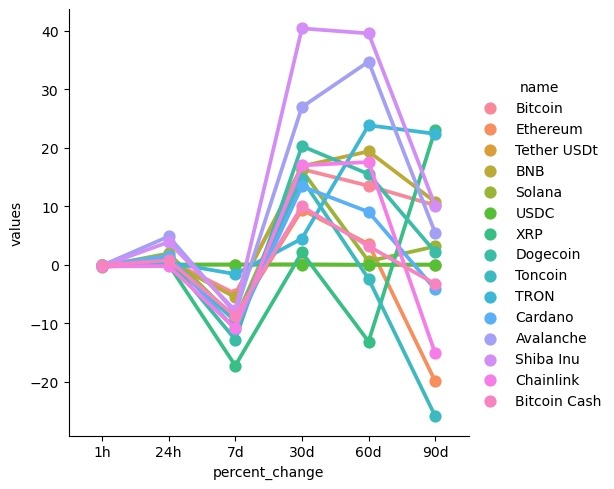

In [124]:
sns.catplot(x="percent_change", y="values", hue="name", data=df8, kind="point");

In [128]:
df9 = df3[["name", "quote.USD.price", "timestamp"]]
df9 = df9.query("name == 'Bitcoin'")
df9

,name,quote.USD.price,timestamp
0,Bitcoin,62518.28700,2024-10-06 22:37:32.601502
15,Bitcoin,62518.28700,2024-10-06 22:38:35.054803
30,Bitcoin,62541.16342,2024-10-06 22:39:37.423558


In [87]:
pd.set_option("display.float_format", lambda x: "%.5f" % x)

In [89]:
df

,id,name,symbol,slug,num_market_pairs,date_added,tags,max_supply,circulating_supply,total_supply,infinite_supply,platform,cmc_rank,self_reported_circulating_supply,self_reported_market_cap,tvl_ratio,last_updated,quote.USD.price,quote.USD.volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.name,platform.symbol,platform.slug,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,11755,2010-07-13T00:00:00.000Z,"[mineable, pow, sha-256, store-of-value, state...",21000000.00000,19764040.00000,19764040.00000,False,NaN,1,NaN,NaN,None,2024-10-06T22:38:00.000Z,62541.16342,14183040578.05482,4.50040,0.01897,0.74943,-4.93960,16.36693,13.56840,10.20981,1236066055400.97095,56.89090,1313364431736.64990,None,2024-10-06T22:38:00.000Z,NaN,NaN,NaN,NaN,NaN,2024-10-06 22:39:37.423558
1,1027,Ethereum,ETH,ethereum,9378,2015-08-07T00:00:00.000Z,"[pos, smart-contracts, ethereum-ecosystem, coi...",NaN,120377344.45751,120377344.45751,True,NaN,2,NaN,NaN,None,2024-10-06T22:37:00.000Z,2426.58095,8228546528.45865,0.26430,-0.29311,0.37658,-8.94021,9.37020,3.57844,-19.86704,292105370575.28674,13.44470,292105370575.28998,None,2024-10-06T22:37:00.000Z,NaN,NaN,NaN,NaN,NaN,2024-10-06 22:39:37.423558
2,825,Tether USDt,USDT,tether,99436,2015-02-25T00:00:00.000Z,"[stablecoin, asset-backed-stablecoin, avalanch...",NaN,119677344821.66928,121372645796.94348,True,NaN,3,NaN,NaN,None,2024-10-06T22:37:00.000Z,0.99991,30351189108.67780,1.98070,-0.02600,-0.04443,-0.02419,0.02773,-0.10576,-0.00702,119666745761.79430,5.50790,121361896595.06000,None,2024-10-06T22:37:00.000Z,1027.00000,Ethereum,ETH,ethereum,0xdac17f958d2ee523a2206206994597c13d831ec7,2024-10-06 22:39:37.423558
3,1839,BNB,BNB,bnb,2252,2017-07-25T00:00:00.000Z,"[marketplace, centralized-exchange, payments, ...",NaN,145932499.03000,145932499.03000,False,NaN,4,NaN,NaN,None,2024-10-06T22:37:00.000Z,566.04216,1386591037.10802,-2.78980,-0.20054,0.48345,-5.58534,16.86777,19.17861,10.78388,82603946897.13255,3.80190,82603946897.13000,None,2024-10-06T22:37:00.000Z,NaN,NaN,NaN,NaN,NaN,2024-10-06 22:39:37.423558
4,5426,Solana,SOL,solana,749,2020-04-10T00:00:00.000Z,"[pos, platform, solana-ecosystem, cms-holdings...",NaN,468586554.36311,585973976.51879,True,NaN,5,NaN,NaN,None,2024-10-06T22:37:00.000Z,145.17373,1119983145.32757,-0.10930,-0.26420,1.85825,-9.30758,16.06634,0.30280,3.29669,68026456316.51645,3.13070,85068025843.06000,None,2024-10-06T22:37:00.000Z,NaN,NaN,NaN,NaN,NaN,2024-10-06 22:39:37.423558
5,3408,USDC,USDC,usd-coin,22306,2018-10-08T00:00:00.000Z,"[medium-of-exchange, stablecoin, asset-backed-...",NaN,35581515660.52821,35581515660.52821,False,NaN,6,NaN,NaN,None,2024-10-06T22:37:00.000Z,0.99995,2472272619.56524,-2.05540,-0.01817,-0.04583,0.00475,-0.00597,-0.08183,-0.00077,35579889928.88250,1.63760,35579889928.88000,None,2024-10-06T22:37:00.000Z,1027.00000,Ethereum,ETH,ethereum,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2024-10-06 22:39:37.423558
6,52,XRP,XRP,xrp,1400,2013-08-04T00:00:00.000Z,"[medium-of-exchange, enterprise-solutions, arr...",100000000000.00000,56564039920.00000,99987161962.00000,False,NaN,7,NaN,NaN,None,2024-10-06T22:38:00.000Z,0.53138,589493065.24286,-15.61200,-0.18528,-0.03188,-17.26156,2.06358,-13.24042,23.11675,30057278939.36972,1.38340,53138493965.21000,None,2024-10-06T22:38:00.000Z,NaN,NaN,NaN,NaN,NaN,2024-10-06 22:39:37.423558
7,74,Dogecoin,DOGE,dogecoin,1076,2013-12-15T00:00:00.000Z,"[mineable, pow, scrypt, medium-of-exchange, me...",NaN,146259236383.70520,146259236383.70520,True,NaN,8,NaN,NaN,None,2024-10-06T22:38:00.000Z,0.11039,423659473.63969,6.88500,-0.31347,0.79026,-12.84759,20.25564,15.36378,2.25416,16145103854.67895,0.74300,16145103854.68000,None,2024-10-06T22:38:00.000Z,NaN,NaN,N